# Dataset tour — the E0 core set

Interactive companion to the `data/` package: what each dataset looks like and
what the shared `[0, π]` preprocessing does.

**This notebook is exploration only, never source of truth** (CLAUDE.md;
`docs/groundwork.md` §3). Everything shown here is computed by the tested
pipeline code — the notebook just calls it. To run it yourself:

```bash
conda env create -f environment.yml && conda activate qml-thesis
jupyter lab notebooks/01_dataset_tour.ipynb
```


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from data import available_datasets, load_dataset
from data.preprocessing import ANGLE_MAX, AngleScaler

# Chart chrome: the validated reference palette used across the project.
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLUE, AQUA, BLUE_DARK = "#2a78d6", "#1baf7a", "#184f95"
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "font.family": "sans-serif", "figure.dpi": 110, "legend.frameon": False,
})
print("repo root:", ROOT)


repo root: /home/user/quantum_ml_vs_traditional_ml-comparison


## The seven core datasets

Loaded through the registry — the only entry point the pipeline itself uses.
All targets are binary `{0, 1}` by construction (groundwork §5/§11).


In [2]:
rows = []
for name in available_datasets():
    X, y, meta = load_dataset(name)
    rows.append({
        "n_samples": meta["n_samples"],
        "n_features": meta["n_features"],
        "class 0": f"{meta['class_counts']['0']}  ({meta['label_map']['0']})",
        "class 1": f"{meta['class_counts']['1']}  ({meta['label_map']['1']})",
        "source": meta["source"].replace("sklearn.datasets.", ""),
    })
pd.DataFrame(rows, index=available_datasets()).rename_axis("dataset")


,n_samples,n_features,class 0,class 1,source
dataset,,,,,
banknote,1372,4,762 (genuine (openml target '1')),610 (forged (openml target '2')),fetch_openml
breast_cancer,569,30,212 (malignant),357 (benign),load_breast_cancer
circles,500,2,250 (outer circle),250 (inner circle),make_circles
digits_3v5,365,64,183 (digit 3),182 (digit 5),load_digits
heart_statlog,270,13,150 (absent),120 (present),fetch_openml
iris_binary,100,4,50 (versicolor),50 (virginica),load_iris
moons,500,2,250 (moon 0),250 (moon 1),make_moons
pima,768,8,500 (tested_negative),268 (tested_positive),fetch_openml
wine_binary,119,13,71 (class_1),48 (class_2),load_wine


## Tier 0 — synthetic sanity checks

Two-dimensional, so the class structure is directly visible. Generation
parameters are frozen inside `data/synthetic.py` (n=500, seed 1234) — the same
arrays every model will ever see.


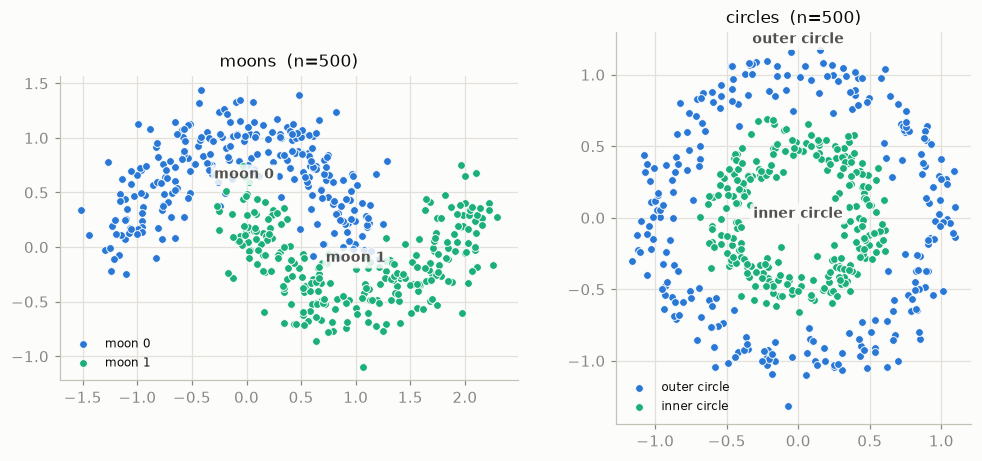

In [3]:
label_pos = {
    ("moons", 0): None, ("moons", 1): None,        # None -> class centroid
    ("circles", 0): (0.0, 1.22), ("circles", 1): (0.0, 0.0),
}
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.3))
for ax, name in zip(axes, ["moons", "circles"]):
    X, y, meta = load_dataset(name)
    for cls, color in ((0, BLUE), (1, AQUA)):
        pts = X[y == cls]
        ax.scatter(pts[:, 0], pts[:, 1], s=26, c=color,
                   edgecolors=SURFACE, linewidths=0.6,
                   label=meta["label_map"][str(cls)])
        pos = label_pos[(name, cls)]
        xy = tuple(pts.mean(axis=0)) if pos is None else pos
        ax.annotate(meta["label_map"][str(cls)], xy, ha="center",
                    fontsize=9, fontweight="bold", color=INK2,
                    bbox=dict(boxstyle="round,pad=0.25", fc=SURFACE,
                              ec="none", alpha=0.85))
    ax.set_title(f"{name}  (n={len(y)})", fontsize=11)
    ax.set_aspect("equal")
    ax.legend(loc="lower left", fontsize=8)
plt.tight_layout()


## Tier 2 — digits, 3 vs 5

The visually confusable pair, kept at full 8×8 resolution by the loader;
PCA-8/16 for quantum models is a config-level step in later experiments.


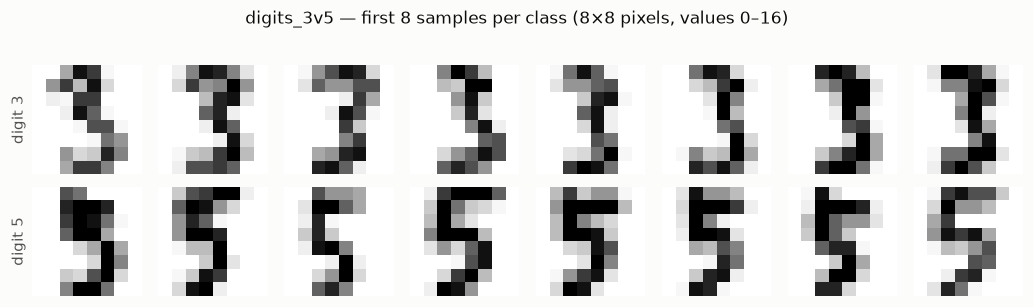

In [4]:
X, y, meta = load_dataset("digits_3v5")
fig, axes = plt.subplots(2, 8, figsize=(9.5, 2.9))
for row, cls in enumerate((0, 1)):
    imgs = X[y == cls][:8]
    for col in range(8):
        ax = axes[row, col]
        ax.imshow(imgs[col].reshape(8, 8), cmap="Greys", vmin=0, vmax=16)
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        for spine in ax.spines.values():
            spine.set_visible(False)
    axes[row, 0].set_ylabel(meta["label_map"][str(cls)], color=INK2, fontsize=10)
fig.suptitle("digits_3v5 — first 8 samples per class (8×8 pixels, values 0–16)",
             fontsize=11)
plt.tight_layout()


## Shared preprocessing — `AngleScaler`

Every model (classical and quantum) consumes the same per-feature min–max
scaling onto `[0, π]`, the angle-encoding range. **The scaler is always fit on
the training fold only** — below we use the stored split `s0_f0` of banknote,
exactly as `experiments/run.py` does, and push the *test* fold through it.
Test values outside the training range are clipped to the bounds.


test-fold values inside [0, π]: True


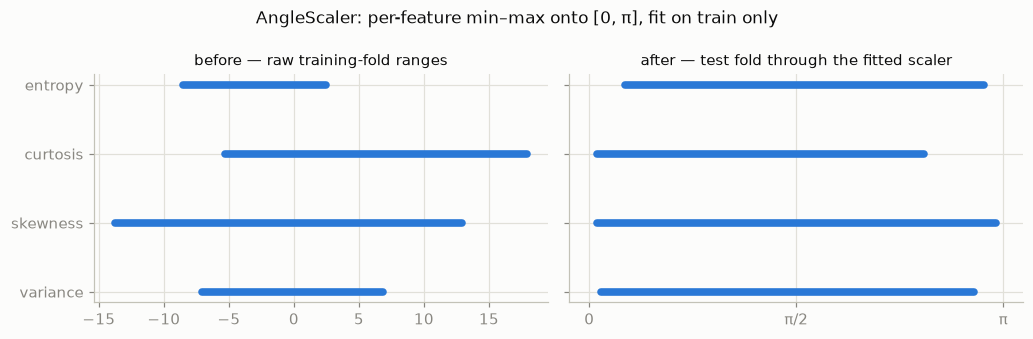

In [5]:
X, y, _ = load_dataset("banknote")
split = json.loads((ROOT / "data" / "splits" / "banknote.json").read_text())["splits"]["s0_f0"]
train_idx, test_idx = np.array(split["train"]), np.array(split["test"])
scaler = AngleScaler().fit(X[train_idx])
X_test_scaled = scaler.transform(X[test_idx])

feats = ["variance", "skewness", "curtosis", "entropy"]   # wavelet features
ypos = np.arange(len(feats))
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.1), sharey=True)
panels = [
    (axes[0], X[train_idx], "before — raw training-fold ranges", None),
    (axes[1], X_test_scaled, "after — test fold through the fitted scaler",
     [0.0, np.pi / 2, np.pi]),
]
for ax, data, title, ticks in panels:
    lo, hi = data.min(axis=0), data.max(axis=0)
    ax.hlines(ypos, lo, hi, color=BLUE, linewidth=5, capstyle="round")
    ax.set_yticks(ypos, feats)
    ax.set_title(title, fontsize=10)
    if ticks is not None:
        ax.set_xticks(ticks, ["0", "π/2", "π"])
        ax.set_xlim(-0.15, np.pi + 0.15)
fig.suptitle("AngleScaler: per-feature min–max onto [0, π], fit on train only",
             fontsize=11)
plt.tight_layout()
print("test-fold values inside [0, π]:",
      bool((X_test_scaled >= 0).all() and (X_test_scaled <= ANGLE_MAX).all()))


Next: **`02_splits_and_runner.ipynb`** — the stored splits' anatomy, running an
experiment through the same code path as the CLI, and reading the results log.
